# LDA Multiclass Dataset — Step-by-Step Jupyter Notebook

## Objective

The objective of this experiment is to understand the limitation on the number of components produced by Linear Discriminant Analysis (LDA).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

In [2]:
# Load dataset
file_path = 'lda_multiclass.csv'
df = pd.read_csv(file_path)

# Display first 5 rows
print(df.head())

         F1         F2        F3        F4        F5  Label
0 -8.467584  -0.777407  1.551185 -1.137861 -4.230311      3
1 -1.351087   9.805949  5.263999  2.601515 -6.891874      0
2 -3.957282   7.606822  3.921435  1.759723 -6.568720      0
3 -7.332416 -11.262207  5.739620  2.782715  4.947252      1
4 -8.669234   9.107922  6.916245 -5.431520 -7.031591      2


In [3]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Unique classes
print("\nUnique Classes:")
print(df.iloc[:, -1].unique())

# Number of classes
num_classes = df.iloc[:, -1].nunique()
print("\nNumber of Classes:", num_classes)

Dataset Shape: (400, 6)

Columns:
Index(['F1', 'F2', 'F3', 'F4', 'F5', 'Label'], dtype='object')

Unique Classes:
[3 0 1 2]

Number of Classes: 4


In [4]:
# Features
X = df.iloc[:, :-1]

# Target labels
y = df.iloc[:, -1]

print("Features Shape:", X.shape)
print("Labels Shape:", y.shape)

Features Shape: (400, 5)
Labels Shape: (400,)


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
# Calculate maximum possible components
max_components = min(X.shape[1], num_classes - 1)

print("Maximum Possible LDA Components:", max_components)

Maximum Possible LDA Components: 3


In [7]:
# Create LDA model
lda = LinearDiscriminantAnalysis(n_components=max_components)

# Transform the dataset
X_lda = lda.fit_transform(X_scaled, y)

print("\nShape After LDA Transformation:", X_lda.shape)


Shape After LDA Transformation: (400, 3)


In [8]:
print("Explained Variance Ratio:")
print(lda.explained_variance_ratio_)

Explained Variance Ratio:
[0.78071621 0.1152426  0.10404119]


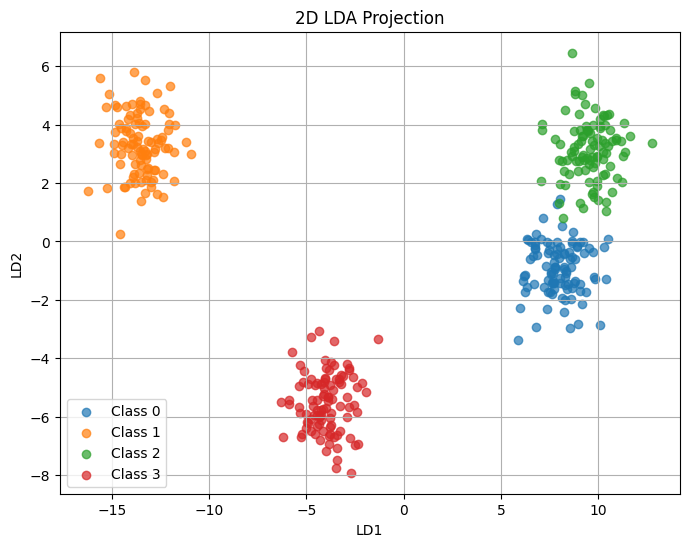

In [9]:
if max_components >= 2:
    plt.figure(figsize=(8, 6))

    for cls in np.unique(y):
        plt.scatter(
            X_lda[y == cls, 0],
            X_lda[y == cls, 1],
            label=f'Class {cls}',
            alpha=0.7
        )

    plt.xlabel('LD1')
    plt.ylabel('LD2')
    plt.title('2D LDA Projection')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("2D projection is not possible.")

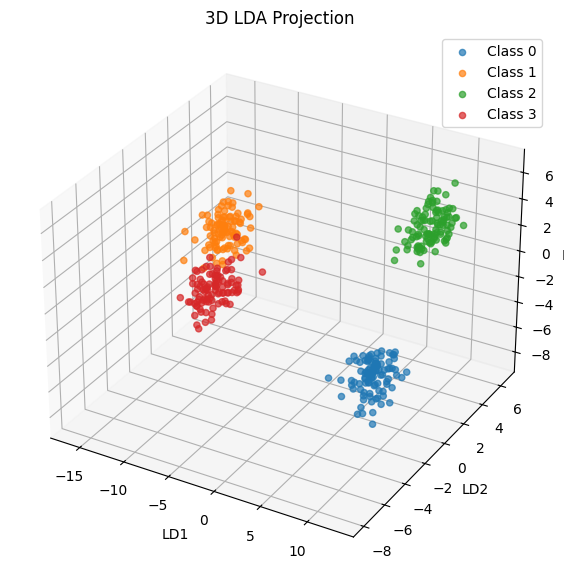

In [10]:
from mpl_toolkits.mplot3d import Axes3D

if max_components >= 3:
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    for cls in np.unique(y):
        ax.scatter(
            X_lda[y == cls, 0],
            X_lda[y == cls, 1],
            X_lda[y == cls, 2],
            label=f'Class {cls}',
            alpha=0.7
        )

    ax.set_xlabel('LD1')
    ax.set_ylabel('LD2')
    ax.set_zlabel('LD3')
    ax.set_title('3D LDA Projection')
    ax.legend()

    plt.show()
else:
    print("3D projection is not possible because sufficient LDA components are unavailable.")

## 1. What is the maximum number of LDA components obtained?

The maximum number of LDA components is:
Maximum Components = min(Number of features,Number of Classes-1)
So, LDA can produce at most:

Number of Classes-1
meaningful discriminant components.


## 2. Verify the Formula

LDA follows the rule:
Components<=(Number of classes-1)


For example:

* If there are **3 classes**, maximum LDA components = **2**
* If there are **4 classes**, maximum LDA components = **3**

This verifies the formula because LDA cannot create more discriminant directions than the number of class separations possible.

---

## 3. Why can’t LDA produce more components?

LDA aims to maximize **class separability**.

If there are (C) classes, only (C - 1) independent directions exist to separate those classes.

This happens because:

* The between-class scatter matrix has rank at most (C - 1)
* Additional components would not provide new discriminative information
* Extra dimensions become redundant for classification

Therefore, LDA is mathematically limited to at most (C - 1) components.

---

## 4. What happens to information beyond these components?

Information beyond the allowed LDA components is discarded.

Specifically:

* LDA keeps only the directions that maximize class separation
* Variance not useful for discrimination is removed
* Some feature information may be lost during dimensionality reduction

Thus:

* Useful discriminative information is preserved
* Non-discriminative information is ignored

This is why LDA acts as both:

* A dimensionality reduction technique
* A supervised learning method


